# The Vasicek Model

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from numpy import maximum, sqrt, exp
from datetime import datetime, timedelta
from dateutil.parser import parse
from dateutil.relativedelta import relativedelta
from datetime import datetime, timedelta
from sqlalchemy import create_engine
import scipy.optimize as spop
from scipy import interpolate
import statsmodels.api as sm
import pyodbc


## The Vacisek Model Properties


1. The vacisek model incorporate mean reversion of the short rate and constant volatility

1. <font color='blue'>**Short rate dynamics under $\mathbb{Q}$:**</font>  The vacisek model is given by <br><br>
$$dr(t) = k \left[ \theta -r(t)\right]dt + \sigma dW^{\mathbb{Q}}(t) $$
$
\begin{align}
\text{where }\\
k &: \text{mean reversion rate} \\
\theta  &: \text{long term mean} \\
\sigma  &: \text{short rate volatility}\\
r_0 &: \text{  represent the initial value of the short rate}
\end{align}
$
<br>

1. <font color='blue'>**Short rate distribution under risk neutral world:**</font> The distribution of the short rate $r(t)$ conditional on $\mathscr{F}_s$ is Normally distributed <br><br> 
$$ r(t) \sim \mathscr{N}\left(  r(s)e^{-k(t-s)} + \theta \left(   1 -  e^{-k(t-s)} \right), \dfrac{\sigma^2}{2k} \left[ 1 -  e^{-2k(t-s)} \right] \right)   $$
<br>

1. <font color='blue'>**Affine properties:**</font> <br><br>
$$P(t,T) = A(t,T)e^{-B(t,T)r(t)}$$
<br>
$
\begin{align}
\text{where }\\
B(t,T) &= \dfrac{1-e^{-k(T-t)}}{k} ,
&A(t,T) =   exp\left[  \left( \theta -  \dfrac{\sigma^2}{2k^2} \right) \left[B(t,T) - T + t \right] - \dfrac{\sigma^2}{4k}B(t,T)  \right]
\end{align}
$
<br><br>

1. <font color='blue'>**Short rate dynamics under $\mathbb{T}$:**</font>  The vacisek model is given by <br><br>
$$dr(t) = \left[ k\theta - B(t,T)\sigma^2 - kr(t)\right]dt + \sigma dW^{\mathbb{T}}(t) $$
$\begin{align}
\text{where }  \\ &dW^{\mathbb{T}}(t) = dW(t) + \sigma B(t,T)dt 
\end{align}
$
<br>
<br>
The distribution of the short rate $r(t)$ conditional on $\mathscr{F}_s$ <br><br> 
$$ r(t)|\mathscr{F}_s \sim \mathscr{N}\left(  r(s)e^{-k(t-s)} + M^T(s,t), \dfrac{\sigma^2}{2k} \left[ 1 -  e^{-2k(t-s)} \right] \right)   $$
<br>
$\begin{align}
\text{where }   && M^T(s,t) =  \left(  \theta - \dfrac{\sigma^2}{k^2}  \right) \left(  1 - e^{-k(t-s)}  \right) +  \dfrac{\sigma^2}{k^2} \left [ e^{-k(T-t) - e^{-k(T+t-2s)}}  \right]
\end{align}
$<br>
<br>

1. <font color='blue'>**Zero Bond Option pricing:**</font> The price at time $t$ of The Zero Bond Option price can be found analytically as <br><br>
$$\text{ZBO}(t, T, S, X) =  \omega\left[  P(t,S)\phi(\omega h) -  X P(t,T)\Phi\left( \omega \left(h-\sigma_p\right) \right) \right]  $$
where
    * $\omega$ : 1 for a call -1 for a put
    * $t$ : todays date
    * $T$ : Maturity date of the option
    * $S$ : Maturity date of the Zero coupon bond
    * $\Phi$ : standard normal cdf
    * $\sigma_p = \sigma \sqrt{    \dfrac{(1 - e^{-2k(T-t)} )}{2k}    }B(T,S) $
    * $h = \dfrac{1}{\sigma_p} \text{ln}\dfrac{P(t,S)}{P(t,T)X}+ 0.5\sigma_p$
<br><br>

1. <font color='blue'>**Dynamics under  $\mathbb{P}$:**</font> under the real world measure we have <br><br>
$$
\begin{align}
dr(t) &= \left[ b -a\cdot r(t)  \right]dt + \sigma dW^{\mathbb{P}}(t) \\ \\
dr(t) &=  \left[ k \theta -( k + \lambda \sigma) r(t)  \right]dt + \sigma dW^{\mathbb{P}}(t) 
\end{align}
$$
<br>
Where the new parameter $\lambda$ represents the market price of risk
The parameters can be estimated from historical timeseries data of the short rate (see $\mathbb{P}$ calibration)
<br><br>

1. <font color='blue'>**Possible shapes:**</font> <br>
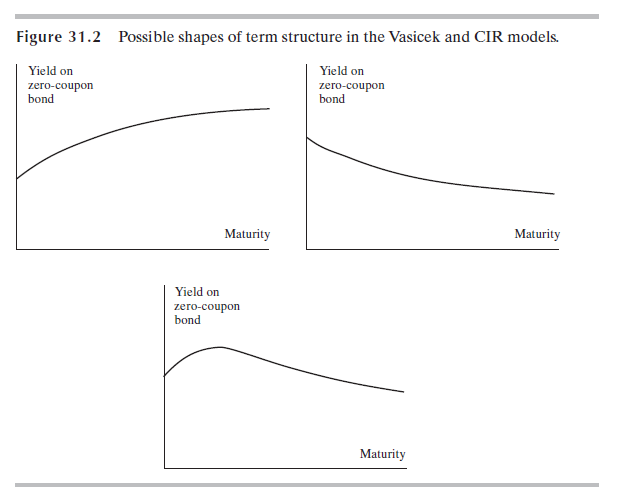

## Calibration 


### Data collection and setup

In the code below we: 
1. Get the SDR curve nodes from our database

1. Fit a yield curve through the terms using spline interpolation

1. define the affine functions $A$ and $B$ to compute the price of zero coupon bonds

1. define a function that returns historical Rates from our database

,Date,R
3585,2023-10-11,0.042639
3586,2023-10-12,0.042675
3587,2023-10-13,0.042573
3588,2023-10-16,0.042705
3589,2023-10-18,0.042787


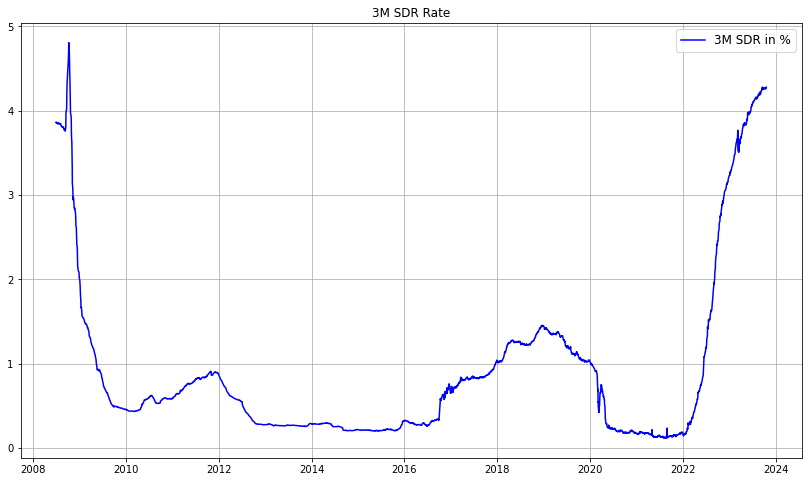

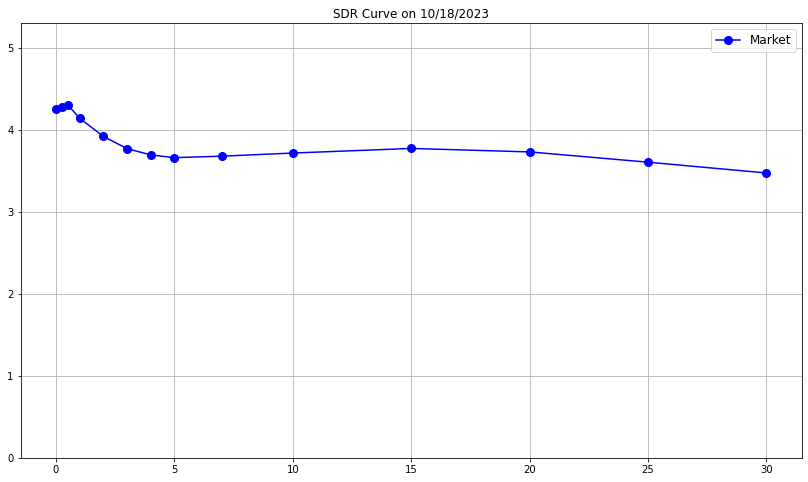

In [2]:
# Define the date for which we want to extract the yield curve
data_date = '10/18/2023'
node = '3M'

# database configuration
db_name = 'PyDB_prod'
server_name = r"wbmsmc101\marketrisk"
connection_str =f"mssql+pyodbc://{server_name}/{db_name}?driver=SQL+Server+Native+Client+11.0"
# conn = create_engine(connection_str).connect()
conn = pyodbc.connect('Driver={SQL Server};'
                      'Server=WBMSMC101\MARKETRISK;'
                      'Database=CROMCDB;'
                      'Trusted_Connection=yes;'
                      'Username=WB\WB548956;')


# this function compute the yield befind a zero coupon bond z
def zero_coupon_to_yield(T, z):
    return -np.log(z)/T*100

def P_vasicek(t, T, k, θ, σ, r_t):
    """
    :param t: valuation date
    :param T: Payment date of ZCB
    :return:
    """
    def A(t, T): 
        return exp((θ - σ ** 2 / (2 * k ** 2)) * (B(t, T) - T + t) - σ ** 2 / (4 * k) * B(t, T) ** 2)

    def B(t, T):
        return 1 / k * (1 - exp(-k * (T - t)))

    P_t_T = A(t, T) * exp(- B(t, T) * r_t)
    return P_t_T

# This function gets historical data
def get_hist_data(DATE, CCY, NODE, nbr_days_calib = 2500, plot_curve = True ):
    # database configuration and getting the data
    db_name = 'PyDB_prod'
    server_name = r"wbmsmc101\marketrisk"
    connection_str = f"mssql+pyodbc://{server_name}/{db_name}?driver=SQL+Server+Native+Client+11.0"
    # conn = create_engine(connection_str).connect()
    sql = f""" select * from 
         (
         SELECT top {nbr_days_calib} 
        [Date] ,[Rate(%)]/100 AS R 
            FROM [PyDB_Prod].[dbo].[SDR_Curves_by_ccy] where CCY = '{CCY}' AND Node = '{NODE}'  AND [Date] <= '{DATE}' ORDER BY DATE desc) as A
            order by Date """
    yield_curve_data = pd.read_sql(sql, conn) 
    display(yield_curve_data.tail())
    
    if plot_curve:
        # plot historical data
        fig = plt.figure(figsize=(14,8)) 
        ax = fig.add_subplot(1,1,1) 
        ax.plot(yield_curve_data['Date'],yield_curve_data['R']*100, linestyle='-', color = 'b',  label = f"{NODE} {CCY} in %" )
        ax.set_title(f'{NODE} SDR Rate'); 
        plt.grid()
        ax.legend(fontsize = 'large');
    
    return yield_curve_data

hist_data = get_hist_data(DATE = data_date , CCY = 'SDR', NODE =node, nbr_days_calib = 250*100, plot_curve = True )

# Define the sql query used to get the SDR yield curve
sql = f""" SELECT Date,Node, [t],[Rate(%)] as r FROM [PyDB_Prod].[dbo].[SDR_Curves_by_ccy]  where date = '{data_date}'  and CCY = 'SDR' Order by t """

# read the data into a dataframe
yield_curve_data = pd.read_sql(sql,conn)
# yield_curve_data['Date'] = yield_curve_data.Date.apply(lambda x: x.date())

# convert the ineterat rates to zero coupon bonds 
yield_curve_data['P(0,T)'] =  np.exp(-yield_curve_data.r*yield_curve_data.t/100.0)   

# Create the yield curve function y(t) using linear interpolation
interpolator = interpolate.splrep(yield_curve_data.t, yield_curve_data.r )
y = lambda t : interpolate.splev(t,interpolator,der=0)

# define the zero coupon bond curve based on the yield curve
P0T_market = lambda T : np.exp(-y(T)/100*T)

# Plot the zero coupon bond curves   
fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(yield_curve_data['t'], y(yield_curve_data['t']), linestyle='-', color = 'b', marker='o', markersize=8,  label = 'Market');
ax.set_title(f'SDR Curve on {data_date}'); 
plt.grid()
plt.ylim([0,max( y(yield_curve_data['t']))+1])
ax.legend(fontsize = 'large');



### $\mathbb{Q}$ - Calibration : Fitting current yield curve


First we defined the objective function
* Let $P(t,T)$ : be the market value of zero coupon bond maturing at time $T$
* Let $\hat P(\Theta; t,T)$ : be the model value of the ZCB given parameter $\Theta$

we want to minimize the root mean squared error RMSE where 

$$ \epsilon = \hat P(\Theta; t,T) - P(t,T)  $$

In [3]:
def vacisek_obj(params):
    k = params[0]
    θ = params[1]
    σ = params[2]
    r0 = params[3]
    
    P0T_martket_zeroes = P0T_market(yield_curve_data.t)
    P0T_model_zeroes =P_vasicek(0,yield_curve_data.t, k,θ, σ,r0 ) 
    
    model_zeroes = zero_coupon_to_yield(yield_curve_data['t'], P0T_model_zeroes )
    martket_zeroes = zero_coupon_to_yield(yield_curve_data['t'],P0T_martket_zeroes)

    ϵ = model_zeroes - martket_zeroes
    squared_errors = ϵ**2
    rmse = np.sqrt(squared_errors.mean())
    return rmse

Here we use Optimization routine to find the parameters

In [4]:
k_init = 0.1  # lamba the mean reversion rate
θ_init = hist_data.R.mean()
σ_init = hist_data.R.std()
r0_init = hist_data.R.values[-1]

cons = {'type': 'ineq', 'fun' : lambda x:  x[2] }

res = spop.minimize(fun=vacisek_obj,
                    x0=[k_init, θ_init, σ_init, r0_init],
                    bounds=[(0.000001, 1), (-0.1, 0.1), (0.0001, 1), (-0.1, 0.1)],
                    constraints= cons
                    )

params = res.x



k = params[0]
θ = params[1]
σ = params[2]
r0 = params[3]

print(f""" The optimal parameters for vacisek are :
k = {k}
θ = {θ}
σ = {σ}
r0 = {r0}
''
the rmse is : {round(res.fun,2)}%
""")

C:\wbg\Anaconda3\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


 The optimal parameters for vacisek are :
k = 0.9836217862402499
θ = 0.035827894434068704
σ = 0.00269153072059649
r0 = 0.04350666181104503
''
the rmse is : 0.08%



Plot curves

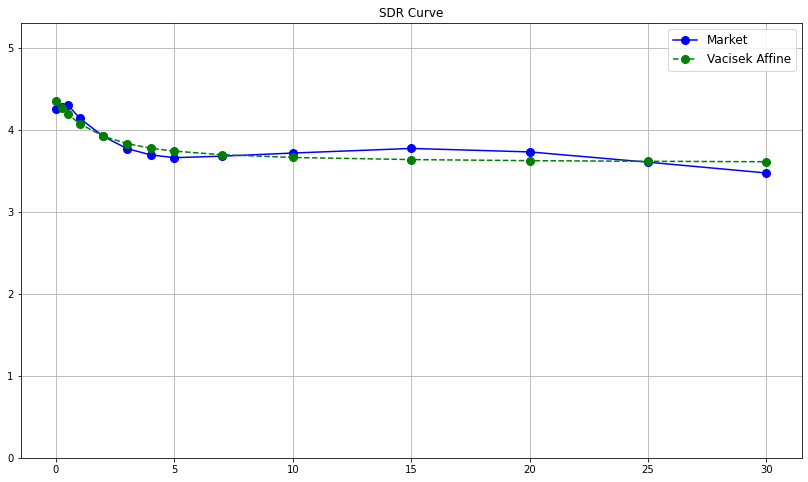

In [5]:
fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(yield_curve_data['t'],
        y(yield_curve_data['t']),
        linestyle='-',
        color = 'b',
        marker='o',
        markersize=8,
        label = 'Market');
plt.grid()

ax.plot(yield_curve_data['t'],
        zero_coupon_to_yield(yield_curve_data['t'], P_vasicek(0,yield_curve_data['t'], k, θ, σ, r0) ),
        linestyle='--',
        color = 'g', 
        marker='o', 
        markersize=8, 
        label = 'Vacisek Affine');

ax.set_title('SDR Curve'); 
plt.grid()
plt.ylim([0,max( y(yield_curve_data['t']))+1])
ax.legend(fontsize = 'large')
plt.grid()

### $\mathbb{P}$ - Calibration 


#### $\mathbb{P}$ - Calibration strategy


1. We estimate the parameters of the vasicek model in $\mathbb{P}$ using historical data  

1. The list of parameters are 

    * $\lambda$ as the market price of risk
    * $k$ as the mean reversion rate
    * $\theta$ -the long term short rate
    * $\sigma$ the volatility parameter
    * $r_0 = $ short rate
    <br><br>
    
1. we consider the historical data for example of SDR 1D as a proxy of the short rate

1. from the historical data we can find
    * $r_0 = $ as the current short rate in the time series
    * $\sigma$ as the volatility does not change between different measure <br><br>

1. We can find $k$ and $\theta$ by
    * fitting to instruments found in the market 
    * using $r_0$ and $\sigma$ as constant in optimization <br><br>
   
1. finally we can find the market price of risk   


#### OLS Calibration method


1. Remember we have 
$$
\begin{align}
dr(t) &= \left[ b -a\cdot r(t)  \right]dt + \sigma dW^{\mathbb{P}}(t) \\ \\
dr(t) &=  \left[ k \theta -( k + \lambda \sigma) r(t)  \right]dt + \sigma dW^{\mathbb{P}}(t) 
\end{align}
$$

1. in regression term this is equivalent to  
$$
\begin{align}
\Delta r_t &= b\Delta_t  -a\Delta_t \cdot r_t  + \sigma z \sqrt{\Delta_t}  \\
   \Delta r_t  &= \beta_0 + \beta_1 r_t + \epsilon
\end{align}
$$

1. Hence by regressing the change in short rate against the short rate we find
    * $\beta_0 = b\Delta_t = k\theta \Delta_t $
    
    * $\beta_1 = - a\Delta_t = -( k + \lambda \sigma) \Delta_t $
    
    * residual error = $\sigma \sqrt{\Delta_t}$ <br><br>
    
    
1. as we can see from the code below we can readily find $r_0$ and $\sigma$ then use the strategy described in the section above

1. In fitting to instrument (zero coupon bonds) we may set as constraint:  $k\times \theta = b$


                            OLS Regression Results                            
Dep. Variable:              Δr_actual   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6997
Date:                Fri, 07 Jun 2024   Prob (F-statistic):              0.403
Time:                        13:06:43   Log-Likelihood:                 26188.
No. Observations:                3589   AIC:                        -5.237e+04
Df Residuals:                    3587   BIC:                        -5.236e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
r_lag          0.0002      0.000      0.836      0.4

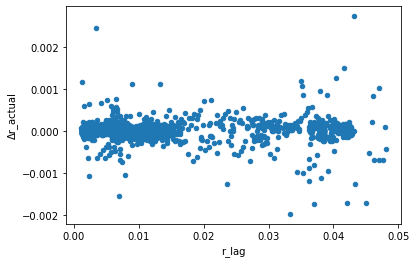

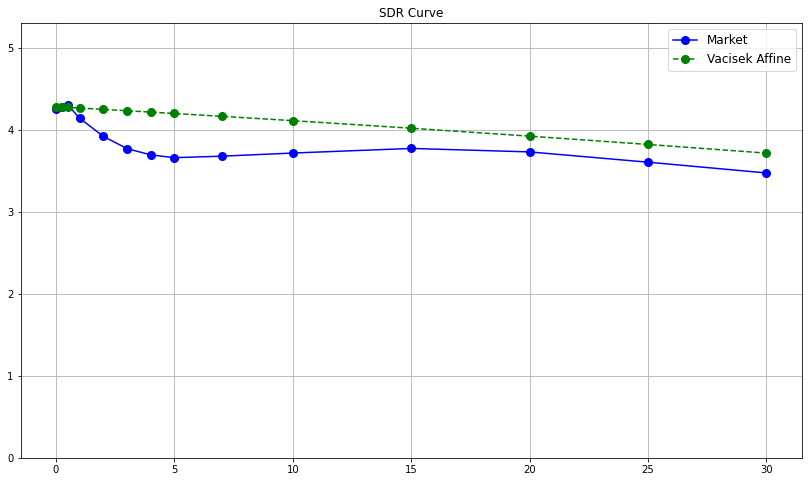

In [6]:
# define objective function with just two parameters k and θ
def vacisek_obj_v2(params):
    k = params[0]
    θ = params[1]
    
    P0T_martket_zeroes = P0T_market(yield_curve_data.t)
    P0T_model_zeroes =P_vasicek(0,yield_curve_data.t, k,θ, σ,r0 ) 
    
    model_zeroes = zero_coupon_to_yield(yield_curve_data['t'], P0T_model_zeroes )
    martket_zeroes = zero_coupon_to_yield(yield_curve_data['t'],P0T_martket_zeroes)

    ϵ = model_zeroes - martket_zeroes
    squared_errors = ϵ**2
    rmse = np.sqrt(squared_errors.mean())
    return rmse

# Finding optimal parameters by linear regression
Δt = 1 / 250.0
hist_data['Δr_actual'] = hist_data.R.diff()
hist_data['r_lag'] = hist_data.R.shift()
hist_data.dropna(inplace=True)
hist_data['Intercept'] = 1
mod = sm.OLS(hist_data.Δr_actual, hist_data[['r_lag', 'Intercept']])
res = mod.fit()

hist_data.plot(kind = 'scatter', x = 'r_lag', y = 'Δr_actual' )

print(res.summary())

β_0 = res.params[1]
β_1 = res.params[0]

b = β_0/ Δt
a = - β_1/ Δt
σ = res.resid.std() / sqrt(Δt)

# get the rates ts r_1, r_2, ...r_n
r = np.array(hist_data.R)
r0 = r[-1]

k_init = b/ hist_data.R.mean()  # lamba the mean reversion rate
θ_init = hist_data.R.mean()


cons = (#{'type': 'ineq', 'fun' : lambda x: 2*x[0]*x[1] - x[2]**2 }, #feller condition
       # {'type': 'eq', 'fun': lambda x:  x[1] - 0.05},  # θ = 4% constraint
       {'type': 'eq', 'fun': lambda x: x[0]*x[1] - b },  # θ = 4% constraint
        
        )


res = spop.minimize(fun=vacisek_obj_v2,
                    x0=[k_init, θ_init],
                    bounds=[(0.000001, 1), (-0.1, 0.1)],
                    constraints= cons
                    )

params = res.x

k = params[0]
θ = params[1]
λ = (a - k)/σ

print(f"""
-------------------------------------
β_0 = {β_0}
β_1 = {β_1}
b = {b}
a = {a}
k = {k}
θ = {θ}
σ = {σ}
r0 = {r0}
λ = {λ}
the rmse is : {round(res.fun,3)}%
""")

fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(yield_curve_data['t'],
        y(yield_curve_data['t']),
        linestyle='-',
        color = 'b',
        marker='o',
        markersize=8,
        label = 'Market');
plt.grid()

ax.plot(yield_curve_data['t'],
        zero_coupon_to_yield(yield_curve_data['t'], P_vasicek(0,yield_curve_data['t'], k, θ, σ, r0) ),
        linestyle='--',
        color = 'g', 
        marker='o', 
        markersize=8, 
        label = 'Vacisek Affine');

ax.set_title('SDR Curve'); 
plt.grid()
plt.ylim([0,max( y(yield_curve_data['t']))+1])
ax.legend(fontsize = 'large')
plt.grid()

#### Closed form max likelyhood method (see brigo mercurio)



-------------------------------------
b = -0.000211303454993963
a = -0.054317023595376504
k = 0.0021131409041043863
θ = -0.09999496710224337
σ = 0.0026035137091473632
r0 = 0.04278738491764761
λ = -21.67461776798612
the rmse is : 0.333%



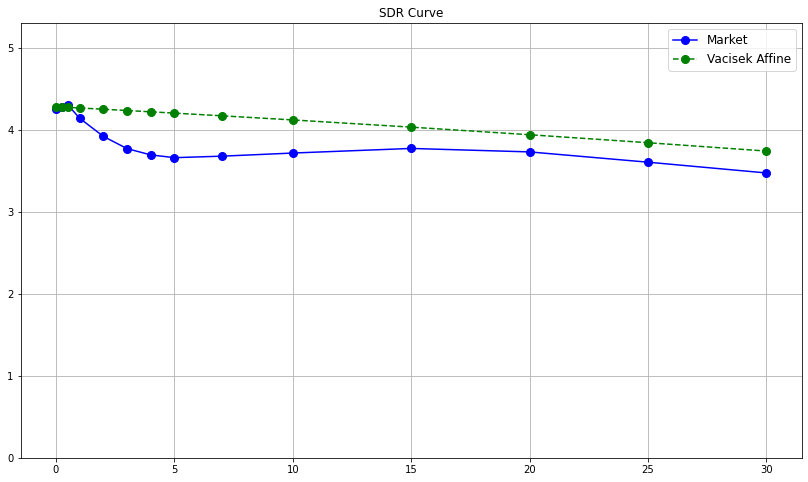

In [7]:
δ = 1.0/252
r = np.array(hist_data.R)
n = len(r)-1
ri = r[1:n]
ri_ = r[0:n-1]
α =   ( n * sum( ri*ri_ ) - sum(ri) * sum(ri_) ) / (n * sum (ri_**2)  - sum(ri_)**2 )
β = ( sum( ri - α * ri_ ) ) / (n * (1-α))
V_squared = 1/n * sum(  (ri - α * ri_ - β * (1- α)) **2 )

a =  - np.log(α) / δ 
b =  β * a
σ = np.sqrt( V_squared / (       (  1 - np.exp(-2*a*δ)  ) / (2 *a)   )        )


# get the rates ts r_1, r_2, ...r_n
r = np.array(hist_data.R)
r0 = r[-1]

k_init = b/ hist_data.R.mean()  # lamba the mean reversion rate
θ_init = hist_data.R.mean()


cons = (#{'type': 'ineq', 'fun' : lambda x: 2*x[0]*x[1] - x[2]**2 }, #feller condition
       # {'type': 'eq', 'fun': lambda x:  x[1] - 0.05},  # θ = 4% constraint
       {'type': 'eq', 'fun': lambda x: x[0]*x[1] - b },  # θ = 4% constraint
        
        )


res = spop.minimize(fun=vacisek_obj_v2,
                    x0=[k_init, θ_init],
                    bounds=[(0.000001, 1), (-0.1, 0.1)],
                    constraints= cons
                    )

params = res.x

k = params[0]
θ = params[1]
λ = (a - k)/σ

print(f"""
-------------------------------------
b = {b}
a = {a}
k = {k}
θ = {θ}
σ = {σ}
r0 = {r0}
λ = {λ}
the rmse is : {round(res.fun,3)}%
""")

fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(yield_curve_data['t'],
        y(yield_curve_data['t']),
        linestyle='-',
        color = 'b',
        marker='o',
        markersize=8,
        label = 'Market');
plt.grid()

ax.plot(yield_curve_data['t'],
        zero_coupon_to_yield(yield_curve_data['t'], P_vasicek(0,yield_curve_data['t'], k, θ, σ, r0) ),
        linestyle='--',
        color = 'g', 
        marker='o', 
        markersize=8, 
        label = 'Vacisek Affine');

ax.set_title('SDR Curve'); 
plt.grid()
plt.ylim([0,max( y(yield_curve_data['t']))+1])
ax.legend(fontsize = 'large')
plt.grid()

## Paths Generation : Exact vs Euler vs Milstein



1. Short rate dynamics under $\mathbb{Q}$ in vacisek model is given by <br><br>
$$dr(t) = k \left[ \theta -r(t)\right]dt + \sigma dW^{\mathbb{Q}}(t) $$

1. Short rate distribution under risk neutral world is Normally distributed <br>
$$ r(t) \sim \mathscr{N}\left(  r(s)e^{-k(t-s)} + \theta \left(   1 -  e^{-k(t-s)} \right), \dfrac{\sigma^2}{2k} \left[ 1 -  e^{-2k(t-s)} \right] \right)   $$

1. In the following we genrate the path via exact, euler and milstein methods

1. Note here the euler and milstein path are equivalent beacuse the diffusion term is a constant


C:\Users\wb548956\AppData\Local\Temp/ipykernel_25484/2439991087.py:19: RuntimeWarning: invalid value encountered in true_divide
  return -np.log(z)/T*100
C:\Users\wb548956\AppData\Local\Temp/ipykernel_25484/2439991087.py:19: RuntimeWarning: invalid value encountered in true_divide
  return -np.log(z)/T*100
C:\Users\wb548956\AppData\Local\Temp/ipykernel_25484/2439991087.py:19: RuntimeWarning: invalid value encountered in true_divide
  return -np.log(z)/T*100


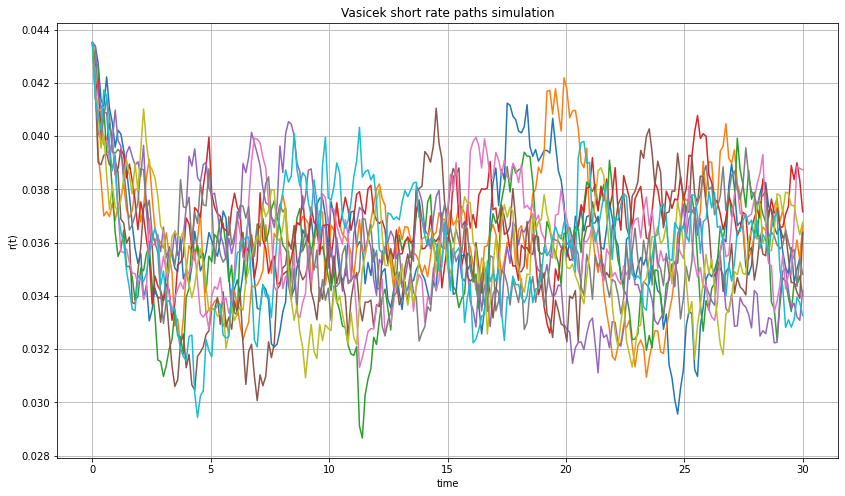

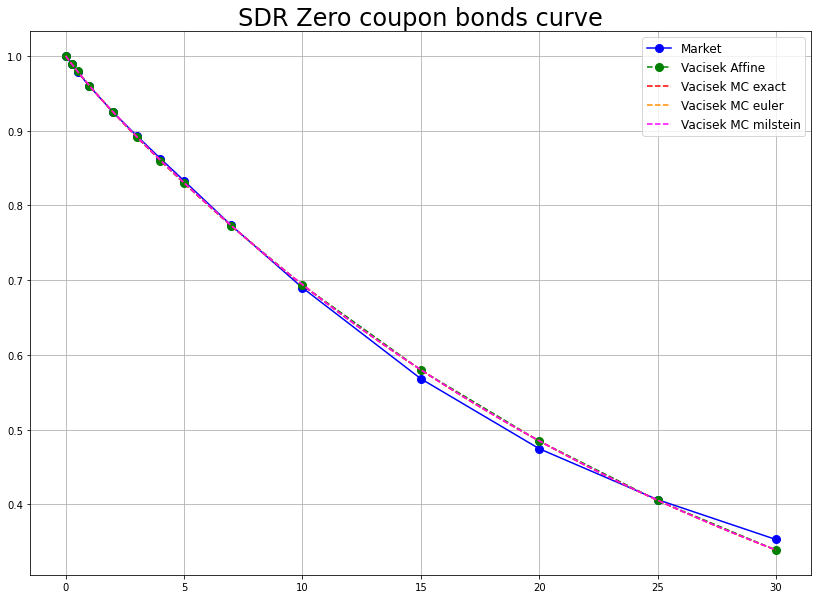

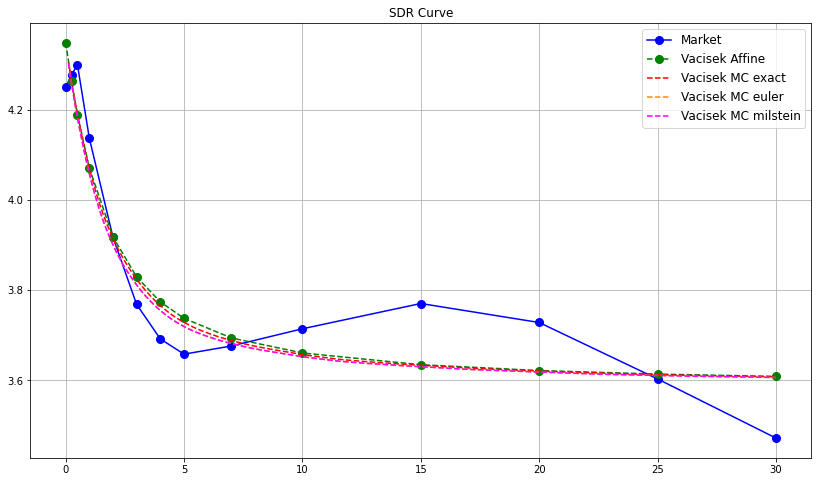

In [8]:
k = 0.9836217862402499
θ = 0.035827894434068704
σ = 0.00269153072059649
r0 = 0.04350666181104503

M = 1_000
N = 250
T = 30

Z = np.random.normal(0.0,1.0,[M ,N ])
W = np.zeros([M , N +1])

r_exact = np.zeros([M , N +1])
r_euler = np.zeros([M , N +1])
r_milstein = np.zeros([M , N +1])

r_exact[:,0]  = r0
r_euler[:,0]  = r0
r_milstein[:,0]  = r0

M_t_exact = np.zeros([M, N+1])
M_t_euler = np.zeros([M, N+1])
M_t_milstein = np.zeros([M, N+1])

M_t_exact[:,0] = 1
M_t_euler[:,0] = 1
M_t_milstein[:,0] = 1

t = np.zeros([N+1]) # time
dt = T / float(N)


def vacisek_exact_paths(k, θ, σ,s, t,  r_s, z):
    μ = r_s * exp( -k * (t-s) )  +  θ * ( 1 - exp( -k * (t-s) )  )
    v = 0.5* 1/k* σ**2 *  ( 1 - exp( -2*k * (t-s) ) )
    r_t = μ + z * sqrt(v) 
    return r_t

def vacisek_euler_paths(k, θ, σ,s, t,  r_s, z):
    dt = t-s
    dWt = z*sqrt(dt)
    r_t = r_s +  k*(θ - r_s) * dt + σ * dWt
    return r_t

def vacisek_milstein_paths(k, θ, σ,s, t,  r_s, z):
    dt = t-s
    dWt = z*sqrt(dt)
    r_t = r_s +  k*(θ - r_s) * dt + σ * dWt +0
    return r_t

for i in range(0,N):
    t[i+1] = t[i] + dt
    
    r_exact[:,i+1] = vacisek_exact_paths(k, θ, σ,t[i], t[i + 1],  r_exact[:, i],Z[:,i] )
    r_euler[:,i+1] = vacisek_euler_paths(k, θ, σ,t[i], t[i + 1],  r_euler[:, i],Z[:,i] )
    r_milstein[:,i+1] = vacisek_milstein_paths(k, θ, σ,t[i], t[i + 1],  r_milstein[:, i],Z[:,i] )
    
    M_t_exact[:, i+1] = M_t_exact[:,i] * np.exp( (r_exact[:, i+1] + r_exact[:, i])* 0.5 * dt)
    M_t_euler[:, i+1] = M_t_euler[:,i] * np.exp( (r_euler[:, i+1] + r_euler[:, i])* 0.5 * dt)
    M_t_milstein[:, i+1] = M_t_milstein[:,i] * np.exp( (r_milstein[:, i+1] + r_milstein[:, i])* 0.5 * dt)
    
    
    
P_t_exact = np.mean(1.0/M_t_exact, axis = 0)
P_t_euler = np.mean(1.0/M_t_euler, axis = 0)
P_t_milstein = np.mean(1.0/M_t_milstein, axis = 0)
P_affine = P_vasicek(0,yield_curve_data['t'], k, θ, σ, r0)

    
fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(t, np.transpose(r_exact[:10,:]), linestyle='-')
plt.grid()
plt.xlabel("time")
plt.ylabel("r(t)");
ax.set_title('Vasicek short rate paths simulation'); 

fig = plt.figure(figsize=(14,10)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
#x.plot(yield_curve_data['t'], yield_curve_data[''], linestyle='-', color = 'r');
ax.plot(yield_curve_data['t'], P0T_market(yield_curve_data['t']), linestyle='-', color = 'b', marker='o', markersize=8,label = 'Market');
ax.plot(yield_curve_data['t'],  P_affine, linestyle='--', color = 'g', marker='o', markersize=8 , label = 'Vacisek Affine');
ax.plot(t, P_t_exact, linestyle='--', color = 'r',label = 'Vacisek MC exact');
ax.plot(t, P_t_euler, linestyle='--',color = 'darkorange', label = 'Vacisek MC euler');
ax.plot(t, P_t_milstein, linestyle='--',color = 'magenta', label = 'Vacisek MC milstein');

ax.set_title('SDR Zero coupon bonds curve', fontsize = 24); 
ax.legend(fontsize = 'large')
plt.grid()
# plt.ylim([0,max(P0T_market(yield_curve_data['t']))*1.1])


fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
 # create a subplot with 1 axis
#x.plot(yield_curve_data['t'], yield_curve_data[''], linestyle='-', color = 'r');
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(yield_curve_data['t'], y(yield_curve_data['t']), linestyle='-', color = 'b', marker='o', markersize=8,  label = 'Market');
ax.plot(yield_curve_data['t'], zero_coupon_to_yield(yield_curve_data['t'], P_affine ), linestyle='--', color = 'g', marker='o', markersize=8, label = 'Vacisek Affine');
ax.plot(t,zero_coupon_to_yield( t, P_t_exact), linestyle='--', color = 'r', label = 'Vacisek MC exact');
ax.plot(t,zero_coupon_to_yield( t, P_t_euler), linestyle='--', color = 'darkorange', label = 'Vacisek MC euler');
ax.plot(t,zero_coupon_to_yield( t, P_t_milstein), linestyle='--',  color = 'magenta', label = 'Vacisek MC milstein');

ax.set_title('SDR Curve'); 
plt.grid()
# plt.ylim([0,max( y(yield_curve_data['t']))+1])
ax.legend(fontsize = 'large');

## Paths error analysis


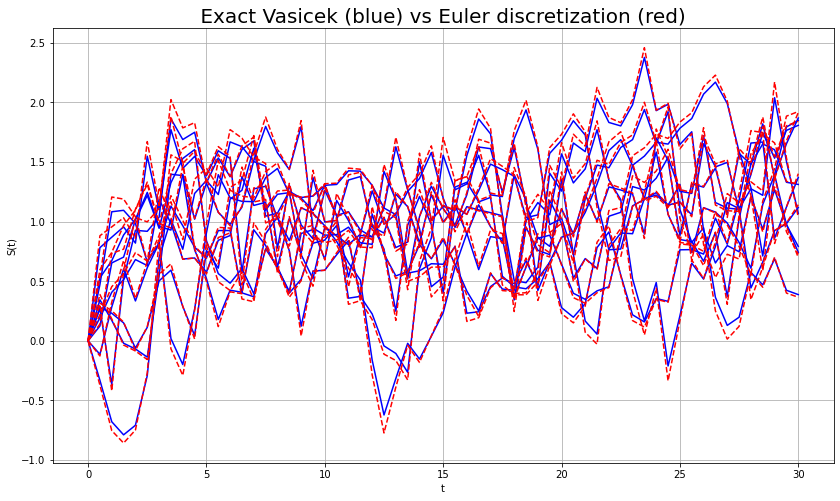

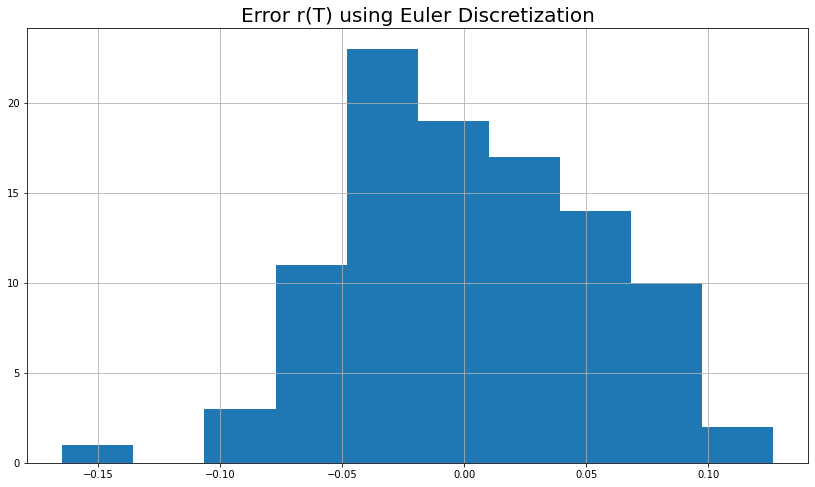

In [9]:
k = 0.5
θ = 1
σ = 0.5
r0 = 0

M = 1_00
N = 60
T = 30
dt = T / float(N)

t = np.zeros([N+1]) # time
Z = np.random.normal(0.0,1.0,[M ,N ])

r_exact = np.zeros([M , N +1])
r_euler = np.zeros([M , N +1])
r_milstein = np.zeros([M , N +1])

r_exact[:,0]  = r0
r_euler[:,0]  = r0

for i in range(0,N):
    t[i+1] = t[i] + dt
    r_exact[:,i+1] = vacisek_exact_paths(k, θ, σ,t[i], t[i + 1],  r_exact[:, i],Z[:,i] )
    r_euler[:,i+1] = vacisek_euler_paths(k, θ, σ,t[i], t[i + 1],  r_euler[:, i],Z[:,i] )
    
exact_S =  r_exact
euler_S =  r_euler


euler_S_T = euler_S[:,-1]
exact_S_T = exact_S[:,-1]

plt.figure( figsize = (14,8))
plt.plot(t, np.transpose(exact_S[0:10,:]), color = 'blue', label = 'Exact Paths')   
plt.plot(t, np.transpose(euler_S[0:10,:]),color = 'red', linestyle = 'dashed', label = 'Euler Paths')   
plt.grid()
plt.xlabel("t")
plt.ylabel("S(t)")
# plt.legend(['Exact Paths','Euler Paths'])
plt.title(' Exact Vasicek (blue) vs Euler discretization (red) ', fontsize=20 );




plt.figure(figsize = (14,8))
plt.hist( exact_S_T - euler_S_T)
plt.grid()
plt.title('Error r(T) using Euler Discretization', fontsize=20 );

